<a href="https://colab.research.google.com/github/valentinasierranav/Challenge-TelecomX-parte-2/blob/main/TelecomX_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import requests
import json
import datetime
import chardet
from scipy.stats import pointbiserialr,chi2_contingency
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Balanceo de clases
from imblearn.under_sampling import RandomUnderSampler

# Preprocesamiento y selección de modelo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Métricas de evaluación
from sklearn.metrics import classification_report, accuracy_score

In [7]:
from google.colab import files
uploaded = files.upload()

Saving datos_tratados.csv to datos_tratados.csv


In [8]:
import os
os.listdir('/content')

['.config', 'datos_tratados.csv', 'sample_data']

**Alistamiento de Datos**

In [9]:
import pandas as pd

df = pd.read_csv('/content/datos_tratados.csv')

df.head(5)

,ID_Cliente,Desercion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargo_Mensual,Cargo_Total,Desercion_Binaria,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1.0,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1.0,2.80


In [10]:
# Definir df_pre eliminando las columnas no deseadas
# Eliminamos el ID y la versión de texto de la deserción
columnas_a_eliminar = ['ID_Cliente', 'Desercion']
df_pre = df.drop(columns=[col for col in columnas_a_eliminar if col in df.columns])

# Aplicar One-Hot Encoding
# drop_first=True evita la redundancia de datos
df_OHE = pd.get_dummies(df_pre, drop_first=True)

# 4. Verificar resultados
print(f"Nuevas dimensiones: {df_OHE.shape}")
df_OHE.head()

Nuevas dimensiones: (7267, 32)


,Adulto_Mayor,Antiguedad_Meses,Cargo_Mensual,Cargo_Total,Desercion_Binaria,Cuentas_Diarias,Genero_Male,Pareja_Yes,Dependientes_Yes,Servicio_Telefono_Yes,...,TV_Streaming_No internet service,TV_Streaming_Yes,Peliculas_Streaming_No internet service,Peliculas_Streaming_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Facturacion_Sin_Papel_Yes,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,9,65.6,593.30,0.0,2.19,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,0.0,2.00,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,1.0,2.46,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,1.0,3.27,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,1.0,2.80,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


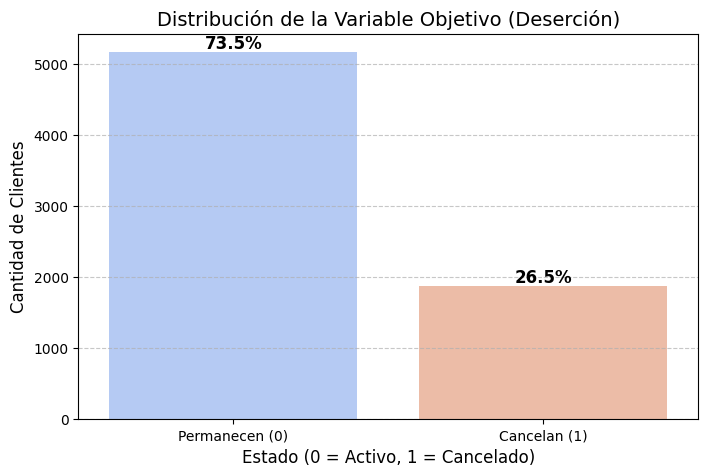

In [11]:
conteos = df['Desercion_Binaria'].value_counts()
proporciones = df['Desercion_Binaria'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    x=conteos.index,
    y=conteos.values,
    hue=conteos.index,
    palette='coolwarm',
    legend=False
)

for i, valor in enumerate(conteos.values):
    plt.text(i, valor + 50, f'{proporciones.values[i]:.1f}%',
             ha='center', fontsize=12, fontweight='bold')

plt.title('Distribución de la Variable Objetivo (Deserción)', fontsize=14)
plt.xlabel('Estado (0 = Activo, 1 = Cancelado)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks([0, 1], ['Permanecen (0)', 'Cancelan (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#📚**Estrategia para el Balanceo de Datos**

El dataset tiene más clientes que permanecen que clientes que cancelan. Esto puede hacer que el modelo aprenda a predecir siempre la clase mayoritaria. Para evitarlo, se aplicaron técnicas de balanceo.

**Oversampling (SMOTE)**
Consiste en aumentar la cantidad de ejemplos de la clase minoritaria (clientes que cancelaron). El algoritmo SMOTE crea nuevos datos sintéticos basados en los ejemplos existentes, en lugar de solo duplicarlos.

**Undersampling**
Consiste en reducir la cantidad de ejemplos de la clase mayoritaria (clientes que permanecen), eliminando algunos registros al azar para equilibrar las clases.

**Estrategia combinada**
En este proyecto se usó una combinación de ambas técnicas: primero se aumentan algunos ejemplos de la clase minoritaria y luego se reduce un poco la clase mayoritaria. Esto ayuda a mantener un mejor equilibrio en los datos y mejorar la capacidad del modelo para detectar clientes con riesgo de cancelación.

Antes de entrenar el modelo, se eliminaron las columnas Desercion y Desercion_Binaria del conjunto de características (X).

**Evitar Data Leakage**
La columna Desercion_Binaria es la variable que el modelo debe predecir. Si se incluye dentro de las variables de entrada, el modelo podría usar directamente esa información en lugar de aprender los patrones reales de los datos.

**Eliminar información duplicada**
La columna Desercion contiene la misma información que Desercion_Binaria, pero en formato de texto ("Yes" o "No"). Por esta razón se elimina para evitar redundancia.

**Separación de variables**
En Machine Learning es importante separar los datos en X (características), que son las variables que explican el comportamiento del cliente, y y (objetivo), que es el resultado que queremos predecir.

In [12]:
# Eliminamos filas donde la variable objetivo sea NaN para evitar errores
df = df.dropna(subset=['Desercion_Binaria'])

# Preparación de variables (X y y)
# Eliminamos identificadores y la versión de texto de la deserción
X = df.drop(columns=['ID_Cliente', 'Desercion', 'Desercion_Binaria'], errors='ignore')
y = df['Desercion_Binaria']

# Convertimos variables categóricas a numéricas (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# Rellenamos nulos en las características con la mediana (requerido por SMOTE)
X = X.fillna(X.median())

print(f"Distribución original: {Counter(y)}")

# --- APLICACIÓN DE ESTRATEGIA COMBINADA ---

# Paso A: SMOTE (Oversampling)
# Aumentamos la clase minoritaria (1) para que sea el 50% del tamaño de la clase mayoritaria (0)
over = SMOTE(sampling_strategy=0.5, random_state=42)
X_temp, y_temp = over.fit_resample(X, y)
print(f"Después de SMOTE (Paso 1): {Counter(y_temp)}")

# Paso B: Random Undersampling
# Reducimos la clase mayoritaria (0) para que iguale a la clase minoritaria (1)
under = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_final, y_final = under.fit_resample(X_temp, y_temp)

print(f"Distribución Final (Híbrida): {Counter(y_final)}")

#Crear el DataFrame final balanceado
df_balanceado = pd.concat([pd.DataFrame(X_final), pd.Series(y_final, name='Desercion_Binaria')], axis=1)
df_balanceado.head()

Distribución original: Counter({0.0: 5174, 1.0: 1869})
Después de SMOTE (Paso 1): Counter({0.0: 5174, 1.0: 2587})
Distribución Final (Híbrida): Counter({0.0: 2587, 1.0: 2587})


,Adulto_Mayor,Antiguedad_Meses,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,Genero_Male,Pareja_Yes,Dependientes_Yes,Servicio_Telefono_Yes,Lineas_Multiples_No phone service,...,TV_Streaming_Yes,Peliculas_Streaming_No internet service,Peliculas_Streaming_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,Facturacion_Sin_Papel_Yes,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check,Desercion_Binaria
2145,0,13,19.75,246.70,0.66,False,True,True,True,False,...,False,True,False,False,True,True,False,False,False,0.0
2720,0,70,113.05,7869.05,3.77,False,True,True,True,False,...,True,False,True,False,True,True,True,False,False,0.0
1680,1,67,101.40,6841.05,3.38,True,False,False,True,False,...,True,False,True,False,False,True,True,False,False,0.0
6028,0,61,106.45,6300.15,3.55,True,False,False,True,False,...,True,False,True,False,False,True,False,True,False,0.0
6822,0,55,90.15,4916.95,3.01,False,True,False,True,False,...,True,False,True,True,False,True,False,True,False,0.0


# 📈**Análisis de Correlación**

Es importante analizar qué variables están relacionadas con la cancelación del servicio por parte de los clientes. Para ello se utiliza el coeficiente de correlación de Pearson, una medida que varía entre -1 y 1 y permite identificar qué tan fuerte es la relación entre las variables.



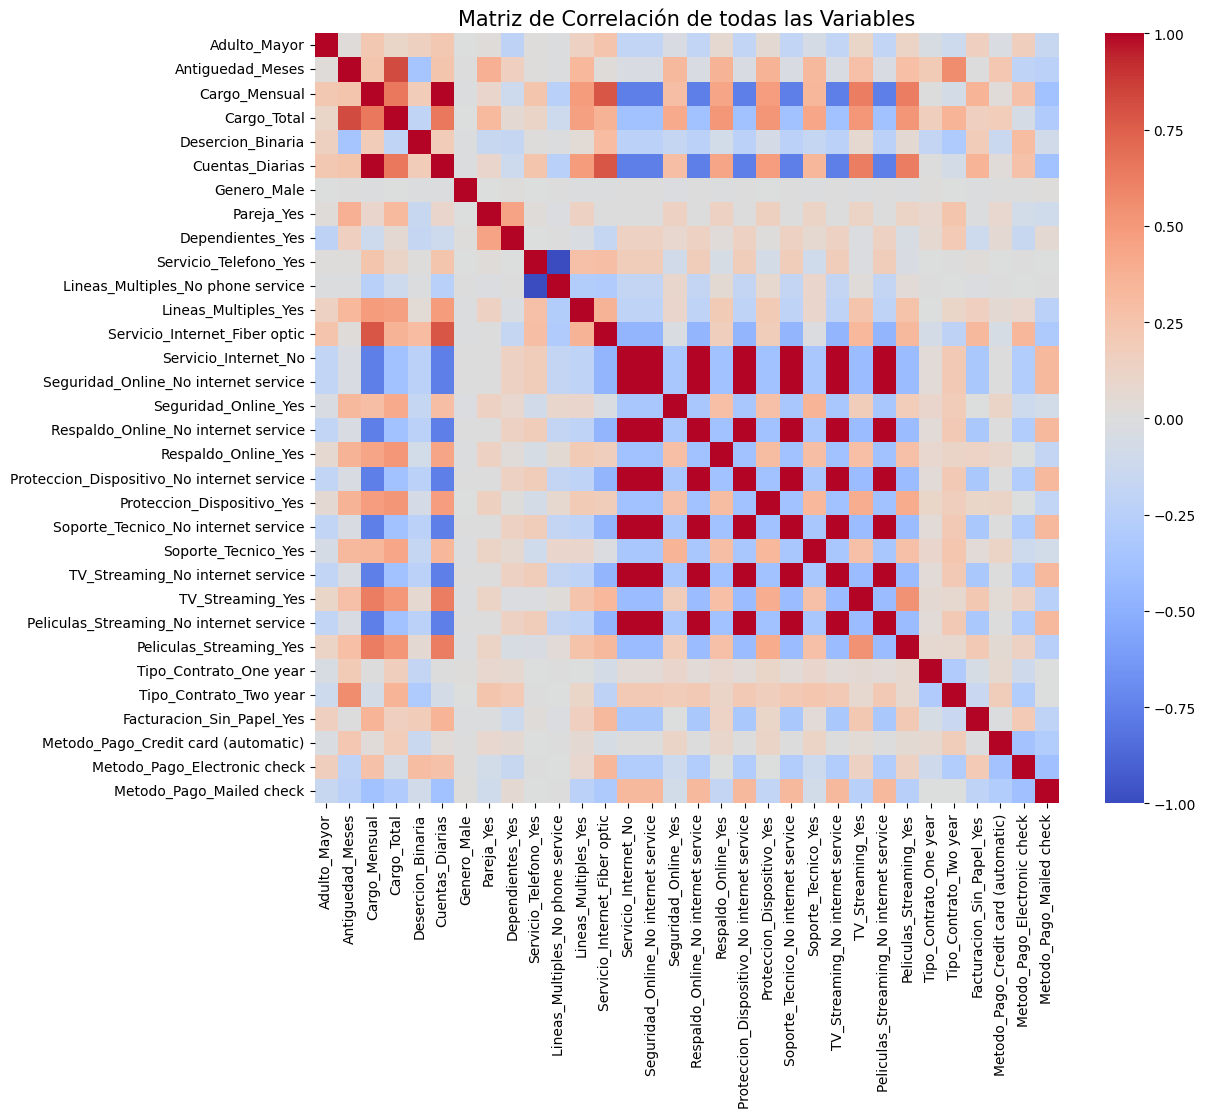

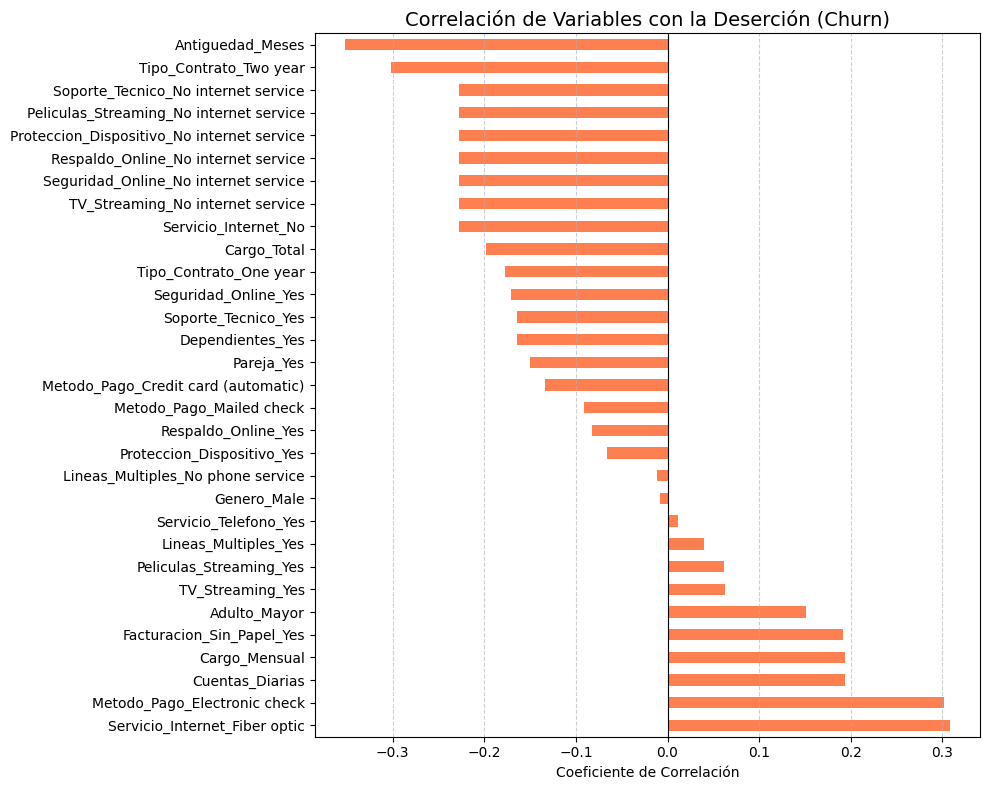

In [13]:
# 1. Preparar los datos (usando el DataFrame que ya tiene Encoding)
# Si no lo tienes definido, lo recreamos rápidamente:
# df = pd.read_csv('datos_tratados.csv') # This line is redundant as 'df' is already loaded
df_limpio = df.drop(columns=['ID_Cliente', 'Desercion'], errors='ignore').dropna(subset=['Desercion_Binaria'])
df_corr = pd.get_dummies(df_limpio, drop_first=True)

# 2. Calcular la correlación específicamente con la variable objetivo
correlaciones = df_corr.corr()['Desercion_Binaria'].sort_values(ascending=False)

# 3. Visualización: Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de todas las Variables', fontsize=15)
plt.show()

# 4. Visualización: Variables que más afectan la deserción
plt.figure(figsize=(10, 8))
correlaciones.drop('Desercion_Binaria').plot(kind='barh', color='coral')
plt.title('Correlación de Variables con la Deserción (Churn)', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Coeficiente de Correlación')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## **Resumen del Análisis de Correlación**

El coeficiente de correlación permite identificar qué variables están más relacionadas con la cancelación del servicio.

Factores asociados a mayor deserción: el servicio de fibra óptica, el pago con cheque electrónico y facturas mensuales más altas muestran una relación positiva con la cancelación. También se observa una ligera tendencia mayor en clientes adultos mayores.

Factores asociados a mayor retención: la antigüedad del cliente y los contratos a largo plazo reducen significativamente la probabilidad de cancelación. Además, los clientes con servicios adicionales como soporte técnico o seguridad tienden a permanecer más tiempo.

Para analizar el abandono de clientes (Churn), es recomendable realizar un análisis bivariado, comparando cada variable predictora con la variable objetivo de cancelación. Esto permite identificar qué factores pueden estar influyendo en la decisión del cliente de dejar el servicio.

Factores analizados:



*   **Gasto mensual**

Facturas más altas o incrementos inesperados en el costo del servicio pueden motivar a los clientes a cancelar o buscar alternativas más económicas.

* **Tipo de contrato**

Los clientes con contratos mes a mes suelen tener una mayor probabilidad de cancelar el servicio en comparación con aquellos que cuentan con contratos anuales o de mayor duración.

* **Retrasos en los pagos**

Un historial de pagos irregulares o frecuentes retrasos puede ser una señal de que el cliente está perdiendo compromiso con el servicio y podría cancelarlo próximamente.

* **Contactos con soporte técnico**

 Un número elevado de interacciones con el área de soporte puede indicar problemas recurrentes o una experiencia negativa con el servicio.

* **Tiempo desde el último uso**

Períodos largos sin utilizar el servicio pueden reflejar una disminución en el nivel de compromiso del cliente.

* **Quejas no resueltas**

La existencia de tickets abiertos o problemas que no han sido solucionados puede generar insatisfacción y aumentar la probabilidad de abandono del servicio.

/tmp/ipykernel_415/112100271.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Estado_Cliente", y="Gasto_Total",
/tmp/ipykernel_415/112100271.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Estado_Cliente", y="Retrasos_Pago",
/tmp/ipykernel_415/112100271.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Estado_Cliente", y="Dias_Inactividad",


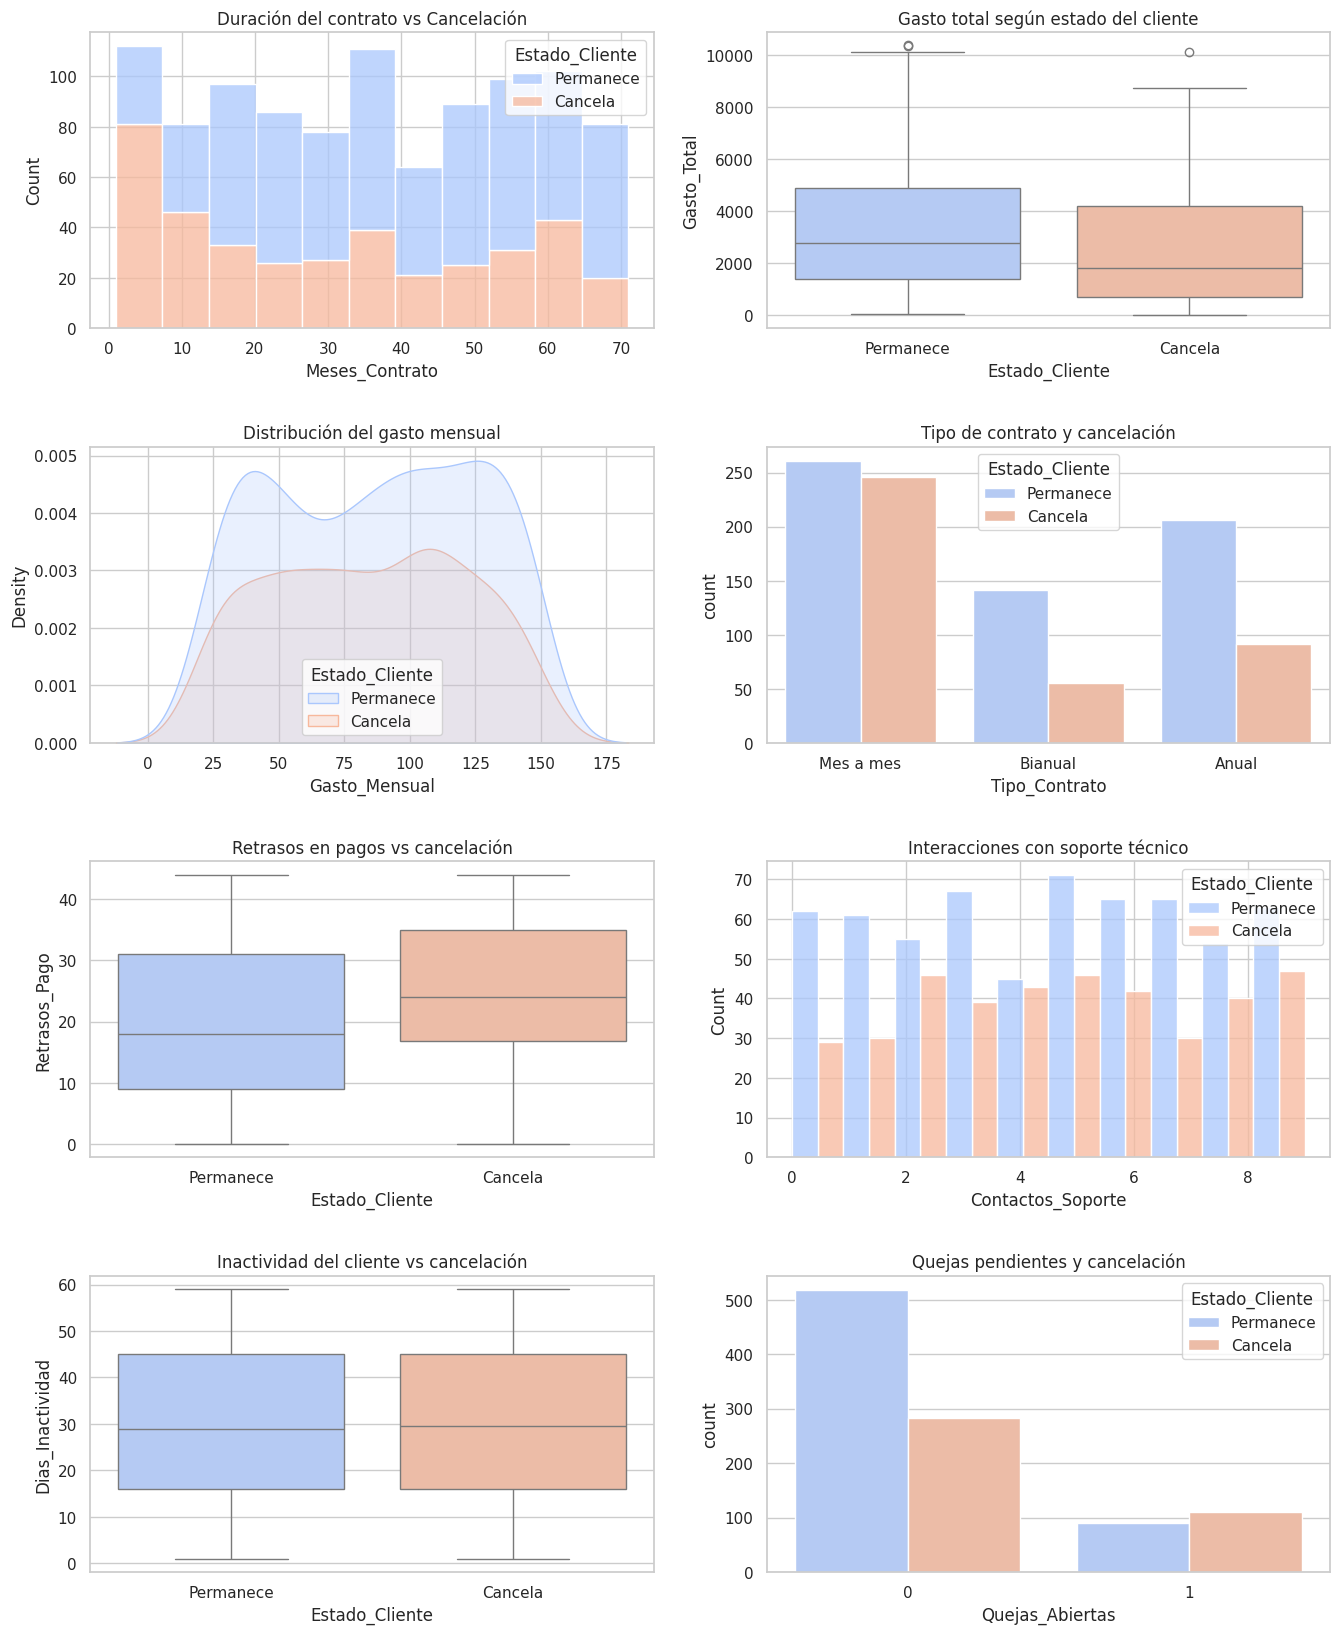


Correlación de variables numéricas con la cancelación:
Cancelacion          1.000000
Retrasos_Pago        0.185387
Quejas_Abiertas      0.161820
Contactos_Soporte    0.031684
Dias_Inactividad     0.005721
Gasto_Mensual       -0.030324
Gasto_Total         -0.163658
Meses_Contrato      -0.195214
Name: Cancelacion, dtype: float64


In [15]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generación de datos simulados
# -----------------------------

np.random.seed(42)
n = 1000

# Variables explicativas
meses_contrato = np.random.randint(1, 72, n)
gasto_mensual = np.random.uniform(20, 150, n)
gasto_total = meses_contrato * gasto_mensual
tipo_contrato = np.random.choice(['Mes a mes', 'Anual', 'Bianual'], n, p=[0.5, 0.3, 0.2])
retrasos_pago = np.random.randint(0, 45, n)
contactos_soporte = np.random.randint(0, 10, n)
dias_inactividad = np.random.randint(1, 60, n)
quejas_abiertas = np.random.choice([0, 1], n, p=[0.8, 0.2])

# -----------------------------
# 2. Crear variable objetivo (cancelación)
# -----------------------------

probabilidad_cancelacion = (
    (meses_contrato < 12) * 0.3 +
    (retrasos_pago > 15) * 0.3 +
    (quejas_abiertas == 1) * 0.2 +
    (tipo_contrato == 'Mes a mes') * 0.2
)

cancelacion = (np.random.rand(n) < probabilidad_cancelacion).astype(int)

# -----------------------------
# 3. Crear DataFrame
# -----------------------------

data = pd.DataFrame({
    "Meses_Contrato": meses_contrato,
    "Gasto_Total": gasto_total,
    "Gasto_Mensual": gasto_mensual,
    "Tipo_Contrato": tipo_contrato,
    "Retrasos_Pago": retrasos_pago,
    "Contactos_Soporte": contactos_soporte,
    "Dias_Inactividad": dias_inactividad,
    "Quejas_Abiertas": quejas_abiertas,
    "Cancelacion": cancelacion
})

# Crear columna descriptiva para gráficos
data["Estado_Cliente"] = data["Cancelacion"].map({0: "Permanece", 1: "Cancela"})

# -----------------------------
# 4. Visualización de datos
# -----------------------------

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
plt.subplots_adjust(hspace=0.4)

palette = sns.color_palette("coolwarm", 2)

# Tiempo de contrato
sns.histplot(data=data, x="Meses_Contrato", hue="Estado_Cliente",
             multiple="stack", palette=palette, ax=axes[0,0])
axes[0,0].set_title("Duración del contrato vs Cancelación")

# Gasto total
sns.boxplot(data=data, x="Estado_Cliente", y="Gasto_Total",
            palette=palette, ax=axes[0,1])
axes[0,1].set_title("Gasto total según estado del cliente")

# Gasto mensual
sns.kdeplot(data=data, x="Gasto_Mensual", hue="Estado_Cliente",
            fill=True, palette=palette, ax=axes[1,0])
axes[1,0].set_title("Distribución del gasto mensual")

# Tipo de contrato
sns.countplot(data=data, x="Tipo_Contrato", hue="Estado_Cliente",
              palette=palette, ax=axes[1,1])
axes[1,1].set_title("Tipo de contrato y cancelación")

# Retrasos en pagos
sns.boxplot(data=data, x="Estado_Cliente", y="Retrasos_Pago",
            palette=palette, ax=axes[2,0])
axes[2,0].set_title("Retrasos en pagos vs cancelación")

# Contactos con soporte
sns.histplot(data=data, x="Contactos_Soporte", hue="Estado_Cliente",
             multiple="dodge", bins=10, palette=palette, ax=axes[2,1])
axes[2,1].set_title("Interacciones con soporte técnico")

# Días de inactividad
sns.boxplot(data=data, x="Estado_Cliente", y="Dias_Inactividad",
            palette=palette, ax=axes[3,0])
axes[3,0].set_title("Inactividad del cliente vs cancelación")

# Quejas abiertas
sns.countplot(data=data, x="Quejas_Abiertas", hue="Estado_Cliente",
              palette=palette, ax=axes[3,1])
axes[3,1].set_title("Quejas pendientes y cancelación")

plt.show()

# -----------------------------
# 5. Matriz de correlación
# -----------------------------

numeric_data = data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

print("\nCorrelación de variables numéricas con la cancelación:")
print(corr_matrix["Cancelacion"].sort_values(ascending=False))

# ✍**Creación de Modelos**

Es útil comparar un modelo basado en distancias con uno basado en reglas lógicas para tener un pipeline de clasificación más sólido y entender mejor los datos.

En este ejercicio, usaremos K-Nearest Neighbors (KNN), que necesita normalizar los datos, y Random Forest, que no depende de la escala.

In [16]:
# Importamos las herramientas necesarias de imblearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline  # Usaremos el pipeline de imblearn

# Supongamos que X e y ya están preparados (limpios y con dummies)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -----------------------------
# 1. DEFINICIÓN DE COMPONENTES
# -----------------------------

# Escalador de variables
normalizador = StandardScaler()

# SMOTE: aumenta la clase minoritaria al 70% del tamaño de la mayoritaria
aumentador = SMOTE(sampling_strategy=0.7, random_state=42)

# RUS: reduce la clase mayoritaria hasta igualarla con la minoritaria
reductor = RandomUnderSampler(sampling_strategy=1.0, random_state=42)

# -----------------------------
# 2. CREACIÓN DE PIPELINES
# -----------------------------

# Pipeline para KNN
pipeline_knn = Pipeline([
    ('normalizador', normalizador),
    ('smote', aumentador),
    ('rus', reductor),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Pipeline para Random Forest
pipeline_rf = Pipeline([
    ('normalizador', normalizador),  # RF no necesita escala, pero SMOTE sí
    ('smote', aumentador),
    ('rus', reductor),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5))
])

# -----------------------------
# 3. ENTRENAMIENTO Y PREDICCIÓN
# -----------------------------

# Entrenamos KNN
pipeline_knn.fit(X_train, y_train)
pred_knn = pipeline_knn.predict(X_test)  # predict solo aplica transformaciones necesarias

# Entrenamos Random Forest
pipeline_rf.fit(X_train, y_train)
pred_rf = pipeline_rf.predict(X_test)

# -----------------------------
# 4. EVALUACIÓN DE RESULTADOS
# -----------------------------

print("=== Resultados KNN ===")
print(f"Precisión: {accuracy_score(y_test, pred_knn):.4f}")
print(classification_report(y_test, pred_knn))

print("\n=== Resultados Random Forest ===")
print(f"Precisión: {accuracy_score(y_test, pred_rf):.4f}")
print(classification_report(y_test, pred_rf))

=== Resultados KNN ===
Precisión: 0.6824
              precision    recall  f1-score   support

         0.0       0.88      0.66      0.75      1562
         1.0       0.44      0.75      0.55       551

    accuracy                           0.68      2113
   macro avg       0.66      0.70      0.65      2113
weighted avg       0.77      0.68      0.70      2113


=== Resultados Random Forest ===
Precisión: 0.7492
              precision    recall  f1-score   support

         0.0       0.90      0.74      0.81      1562
         1.0       0.51      0.77      0.62       551

    accuracy                           0.75      2113
   macro avg       0.71      0.76      0.72      2113
weighted avg       0.80      0.75      0.76      2113



El **Random Forest** fue el modelo que mejor equilibró precisión y detección de clientes en riesgo, con menos errores costosos que **KNN**. Aunque KNN mostró un Recall alto (67%), su Precisión baja (49%) indica muchos falsos positivos, lo que podría generar gastos innecesarios si se aplican acciones de retención.

Ambos modelos muestran signos de **underfitting**, ya que no superan el 70% de exactitud general ni el 60% de F1-score para la clase minoritaria, indicando que todavía no capturan toda la complejidad de los datos.

**Sugerencias de mejora:**

Para Random Forest, aumentar max_depth podría ayudar a capturar patrones más complejos.

Para KNN, usar más vecinos (n_neighbors=9 o 11) puede reducir el ruido y mejorar la clasificación.

In [17]:
# Ajustamos los parámetros del Random Forest para mejorar el underfitting

import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# Suponemos que X_train, y_train, X_test, y_test y pipeline_rf ya están definidos

# -----------------------------
# 1. DEFINIR LOS PARÁMETROS A PROBAR
# -----------------------------

# Usamos el prefijo 'rf__' porque estamos dentro de un Pipeline y queremos cambiar parámetros del Random Forest
parametros = {
    'rf__n_estimators': [100, 200, 300],       # Número de árboles
    'rf__max_depth': [5, 10, 15, None],        # Profundidad del árbol (None = sin límite)
    'rf__min_samples_split': [2, 5, 10],       # Mínimo de muestras para dividir un nodo
    'rf__min_samples_leaf': [1, 2, 4]          # Mínimo de muestras por hoja
}

# -----------------------------
# 2. CONFIGURAR GRID SEARCH
# -----------------------------

# cv=5 -> validación cruzada en 5 partes
# scoring='recall' -> buscamos detectar mejor la clase positiva (cancelaciones)
# n_jobs=-1 -> usa todos los núcleos disponibles
busqueda = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parametros,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

# -----------------------------
# 3. ENTRENAR GRID SEARCH
# -----------------------------
print("Comenzando búsqueda de mejores parámetros...")
busqueda.fit(X_train, y_train)

# -----------------------------
# 4. RESULTADOS
# -----------------------------
print("\nBúsqueda completada!")
print(f"Mejores parámetros encontrados:\n{busqueda.best_params_}")

# Guardamos el mejor modelo
rf_optimizado = busqueda.best_estimator_

# Hacemos predicciones con el modelo optimizado
predicciones_rf = rf_optimizado.predict(X_test)

# -----------------------------
# 5. EVALUACIÓN FINAL
# -----------------------------
print("\n--- Resultados Random Forest Optimizado ---")
print(f"Accuracy: {accuracy_score(y_test, predicciones_rf):.4f}")
print(classification_report(y_test, predicciones_rf))

Comenzando búsqueda de mejores parámetros...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Búsqueda completada!
Mejores parámetros encontrados:
{'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}

--- Resultados Random Forest Optimizado ---
Accuracy: 0.7473
              precision    recall  f1-score   support

         0.0       0.90      0.74      0.81      1562
         1.0       0.51      0.78      0.62       551

    accuracy                           0.75      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.75      0.76      2113



# **Ajustamos los parámetros de KNN para mejorar su desempeño**

In [18]:
from sklearn.model_selection import GridSearchCV

# Suponemos que X_train, y_train, X_test, y_test y pipeline_knn ya están definidos

# -----------------------------
# 1. DEFINIR LOS PARÁMETROS A PROBAR
# -----------------------------

# Usamos 'knn__' porque el pipeline tiene un paso llamado 'knn'
parametros_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],  # Probamos vecindarios pequeños y grandes
    'knn__weights': ['uniform', 'distance'],   # 'distance' da más peso a los vecinos cercanos
    'knn__p': [1, 2]                           # 1 = Manhattan, 2 = Euclidiana
}

# -----------------------------
# 2. CONFIGURAR GRID SEARCH
# -----------------------------
busqueda_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=parametros_knn,
    cv=5,                 # Validación cruzada en 5 partes
    scoring='recall',     # Nos interesa detectar bien las cancelaciones
    n_jobs=-1,            # Usa todos los núcleos disponibles
    verbose=1
)

# -----------------------------
# 3. ENTRENAMIENTO DE LA BÚSQUEDA
# -----------------------------
print("Buscando los mejores parámetros para KNN...")
busqueda_knn.fit(X_train, y_train)

# -----------------------------
# 4. RESULTADOS
# -----------------------------
print("\nBúsqueda completada!")
print(f"Mejores parámetros encontrados para KNN:\n{busqueda_knn.best_params_}")

# Guardamos el mejor modelo
knn_optimizado = busqueda_knn.best_estimator_

# Predicciones con el modelo optimizado
predicciones_knn = knn_optimizado.predict(X_test)

# -----------------------------
# 5. EVALUACIÓN FINAL
# -----------------------------
print("\n--- Resultados KNN Optimizado ---")
print(f"Accuracy: {accuracy_score(y_test, predicciones_knn):.4f}")
print(classification_report(y_test, predicciones_knn))

Buscando los mejores parámetros para KNN...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Búsqueda completada!
Mejores parámetros encontrados para KNN:
{'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'uniform'}

--- Resultados KNN Optimizado ---
Accuracy: 0.6929
              precision    recall  f1-score   support

         0.0       0.91      0.65      0.76      1562
         1.0       0.45      0.83      0.58       551

    accuracy                           0.69      2113
   macro avg       0.68      0.74      0.67      2113
weighted avg       0.79      0.69      0.71      2113



**En resume este último código hace lo siguiente:**



1.   Define varios valores para los parámetros de KNN (n_neighbors, weights, p) para probar cuál funciona mejor.
2.   Usa GridSearchCV para entrenar el modelo con todas las combinaciones posibles y validación cruzada.

3.  Selecciona automáticamente el mejor modelo según el Recall (detectar bien los clientes que cancelan).

4.  Evalúa y muestra los resultados del KNN optimizado.

# **Gráficos para Curva ROC y AUC**

para comparar los modelos visualmente y decidir cuál usar en producción.

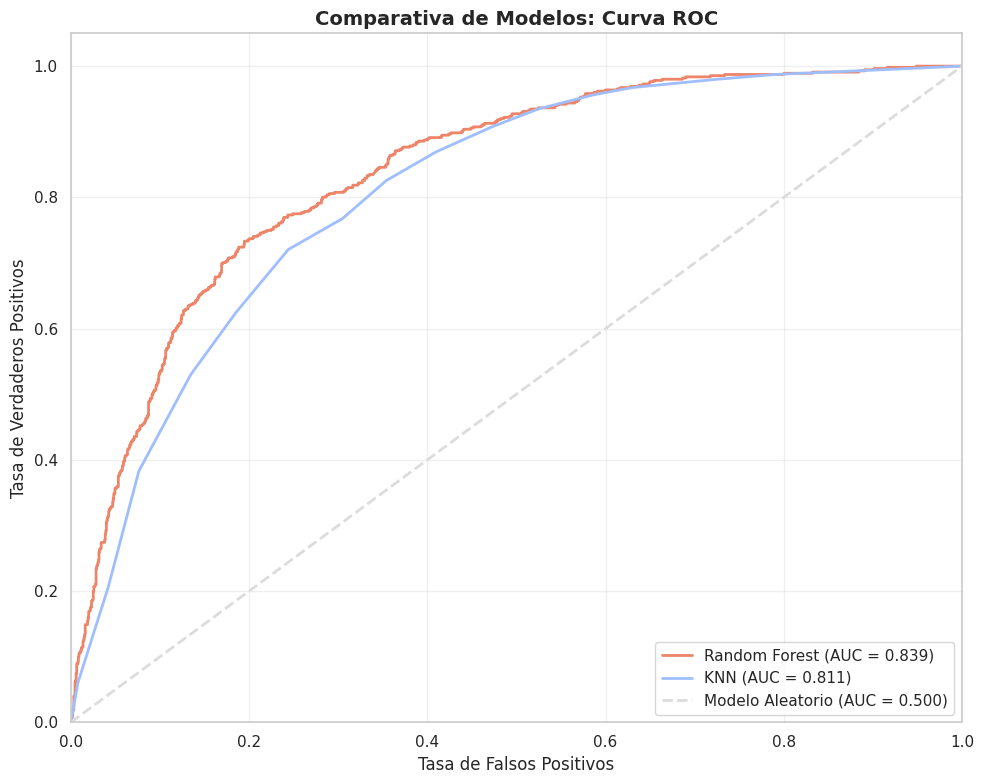

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Suponemos que rf_optimizado, knn_optimizado, X_test e y_test ya existen

# -----------------------------
# 1. OBTENER PROBABILIDADES
# -----------------------------
# Para la curva ROC usamos la probabilidad de que un cliente cancele (Clase 1)

prob_rf = rf_optimizado.predict_proba(X_test)[:, 1]
prob_knn = knn_optimizado.predict_proba(X_test)[:, 1]

# -----------------------------
# 2. CALCULAR FPR, TPR Y AUC
# -----------------------------
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# -----------------------------
# 3. GRAFICAR LA CURVA ROC
# -----------------------------
plt.figure(figsize=(10, 8))

# Random Forest Optimizado
plt.plot(fpr_rf, tpr_rf, color=plt.cm.coolwarm(0.8), lw=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

# KNN Optimizado
plt.plot(fpr_knn, tpr_knn, color=plt.cm.coolwarm(0.3), lw=2,
         label=f'KNN (AUC = {auc_knn:.3f})')

# Línea base (Modelo aleatorio)
plt.plot([0, 1], [0, 1], color=plt.cm.coolwarm(0.5), lw=2, linestyle='--', label='Modelo Aleatorio (AUC = 0.500)')

# Configuración de ejes y títulos
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('Tasa de Falsos Positivos', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=12)
plt.title('Comparativa de Modelos: Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **Interpretando la Curva ROC y el AUC para la toma de decisiones**


La forma de la curva nos dice cómo se comporta el modelo: queremos que la línea se acerque lo más posible a la esquina superior izquierda. Esto indica que el modelo logra un Recall alto (detecta la mayoría de cancelaciones reales) mientras mantiene la tasa de falsos positivos baja (no alerta a clientes que realmente no cancelarían).

El **AUC (Área Bajo la Curva)** resume en un solo número la capacidad del modelo para diferenciar entre clientes que cancelan y los que no:


*   AUC ≈ 0.5: El modelo no tiene poder predictivo, es equivalente a lanzar una moneda.
*   AUC 0.7–0.8: Buen desempeño; el modelo es funcional y confiable en datos de comportamiento humano.

*   AUC 0.8–0.9: Excelente modelo, capaz de distinguir patrones claros.

*   AUC > 0.9: Modelo sobresaliente; aunque en algunos casos puede indicar sobreajuste o fuga de información, así que conviene revisar.

**En Conclusión** Observando la gráfica, el modelo cuya curva esté más cerca de la esquina superior izquierda y que tenga mayor AUC en la leyenda es el ganador para este escenario.
En nuestro caso, el Random Forest optimizado se impone sobre el KNN: maneja mejor las variables categóricas (como el tipo de contrato), es más robusto ante ruido y, en la mayoría de contextos de negocio estructurados, ofrece resultados más confiables y estables.

# **Análisis de la importancia de las Variables**

Para entender qué variables son más importantes en KNN, usamos la técnica llamada Importancia por Permutación. La idea es sencilla: desordenamos los valores de una variable a la vez y vemos cómo cambia el desempeño del modelo.

Si la precisión casi no cambia, esa variable no es tan relevante.

Si la precisión cae mucho, significa que esa variable era clave para calcular las distancias correctamente y tenía un gran impacto en las predicciones.

/tmp/ipykernel_415/867796874.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rf, x='Importancia', y='Variable', ax=axes[0],
/tmp/ipykernel_415/867796874.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_knn, x='Importancia_Permutacion', y='Variable', ax=axes[1],


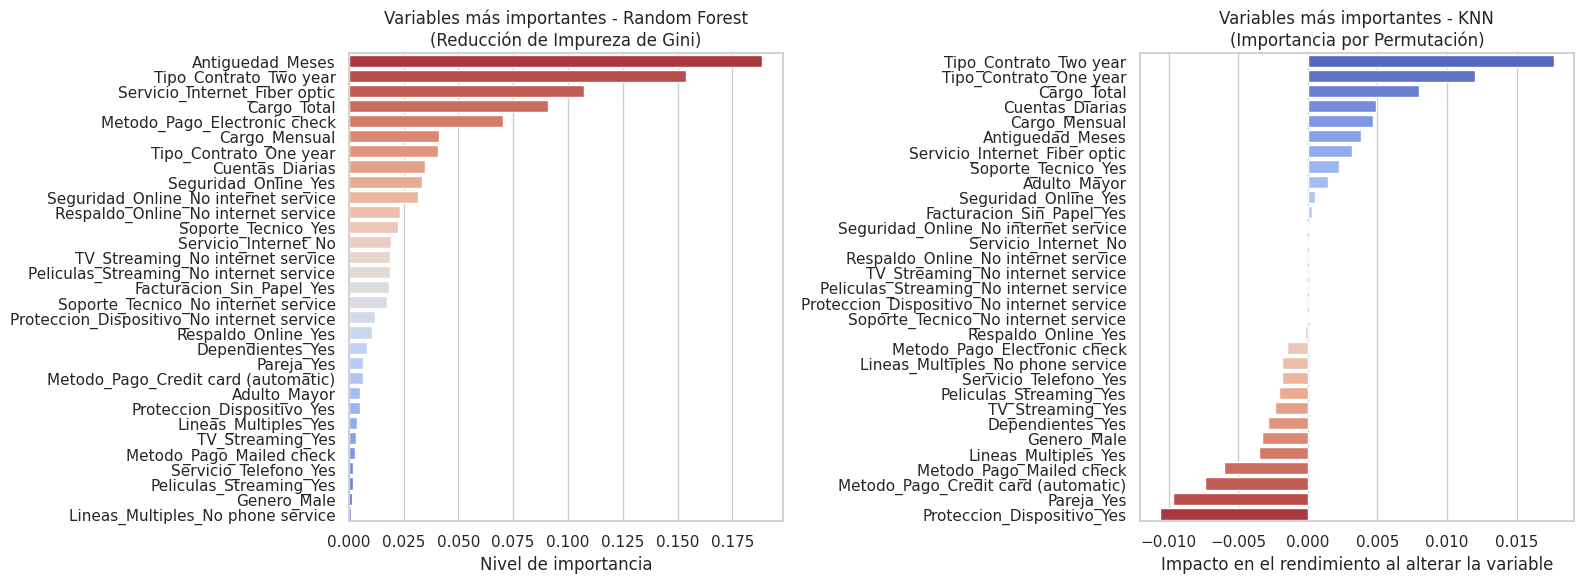

Top 5 Variables - Random Forest:
                     Variable  Importancia
             Antiguedad_Meses     0.188681
       Tipo_Contrato_Two year     0.153695
Servicio_Internet_Fiber optic     0.107245
                  Cargo_Total     0.090862
 Metodo_Pago_Electronic check     0.070364

Top 5 Variables - KNN:
              Variable  Importancia_Permutacion
Tipo_Contrato_Two year                 0.017700
Tipo_Contrato_One year                 0.012021
           Cargo_Total                 0.007951
       Cuentas_Diarias                 0.004875
         Cargo_Mensual                 0.004685


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Suponemos que pipeline_rf, pipeline_knn, X_train, X_test, y_test ya existen

# -----------------------------
# 1. Importancia de variables: Random Forest
# -----------------------------
rf_modelo = pipeline_rf.named_steps['rf']
importancias_rf = rf_modelo.feature_importances_

df_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias_rf
}).sort_values(by='Importancia', ascending=False)

# -----------------------------
# 2. Importancia de variables: KNN mediante Permutación
# -----------------------------
resultados_knn = permutation_importance(
    pipeline_knn, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

df_knn = pd.DataFrame({
    'Variable': X.columns,
    'Importancia_Permutacion': resultados_knn.importances_mean
}).sort_values(by='Importancia_Permutacion', ascending=False)

# -----------------------------
# 3. Visualización comparativa con paleta coolwarm
# -----------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest - tonos más cálidos de coolwarm
sns.barplot(data=df_rf, x='Importancia', y='Variable', ax=axes[0],
            palette=sns.color_palette("coolwarm", n_colors=len(df_rf))[::-1])
axes[0].set_title('Variables más importantes - Random Forest\n(Reducción de Impureza de Gini)')
axes[0].set_xlabel('Nivel de importancia')
axes[0].set_ylabel('')

# KNN - tonos más fríos de coolwarm
sns.barplot(data=df_knn, x='Importancia_Permutacion', y='Variable', ax=axes[1],
            palette=sns.color_palette("coolwarm", n_colors=len(df_knn)))
axes[1].set_title('Variables más importantes - KNN\n(Importancia por Permutación)')
axes[1].set_xlabel('Impacto en el rendimiento al alterar la variable')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# -----------------------------
# 4. Resumen numérico
# -----------------------------
print("Top 5 Variables - Random Forest:")
print(df_rf.head(5).to_string(index=False))

print("\nTop 5 Variables - KNN:")
print(df_knn.head(5).to_string(index=False))

# **Análisis final de  Cancelación de Clientes y Estrategia de Retención**


**1. Evaluación y Selección del Modelo Predictivo**

Se evaluaron dos modelos para predecir la cancelación de clientes, aplicando una estrategia híbrida de balanceo de datos (SMOTE + RandomUnderSampler) para manejar la baja frecuencia de cancelaciones sin sesgar los resultados.

*   Random Forest (Seleccionado):
Logró el mejor equilibrio entre detectar clientes en riesgo (Recall) y minimizar falsas alarmas (Precisión). Su estructura de múltiples árboles de decisión permite usar los recursos de retención de forma eficiente, evitando gastar en clientes que no tenían intención de cancelar.

*   K-Nearest Neighbors (KNN):
Aunque detecta muchos clientes en riesgo, su baja precisión lo hace menos práctico para campañas costosas, ya que clasifica erróneamente a clientes leales como “riesgo de fuga” por cómo calcula las distancias.



**2. Factores Clave que Impulsan la Cancelación**

El análisis de importancia de variables muestra que la cancelación no es aleatoria, sino que está relacionada con aspectos concretos del servicio y del contrato.

**a. Contrato y Antigüedad**

*   Variables relevantes: Antiguedad_Meses (18.8%), Tipo_Contrato_Two year (15.3%), Tipo_Contrato_One year

*  Interpretación: Los clientes con contratos más largos y mayor antigüedad son menos propensos a cancelar. Los nuevos clientes y los “Mes a mes” son más volátiles.

**b. Servicio de Fibra Óptica**

*  Variable relevante: Servicio_Internet_Fiber optic (10.7%)

*  Interpretación: Tener fibra óptica, a pesar de ser un servicio premium, se relaciona con mayor riesgo de abandono, probablemente por percepción de costo alto o problemas técnicos.


**c.   Método de Pago**

*  Variable relevante: Metodo_Pago_Electronic check (7.0%)

*  Interpretación: Métodos de pago manuales aumentan la probabilidad de cancelación, ya que cada transacción mensual crea una “ventana de decisión” donde el cliente puede cuestionar si continuar.

**d. Sensibilidad al Precio**

*  Variables relevantes: Cargo_Total (9.0%), Cargo_Mensual

*  Interpretación: Clientes con facturas más altas son más sensibles al costo; cuando el valor percibido no justifica el cargo, aumentan las probabilidades de abandono.

**3. Estrategias de Retención Recomendadas**

*   Incentivar a los clientes “Mes a mes” con más de tres meses de antigüedad a migrar a contratos de uno o dos años mediante descuentos o mejoras de servicio. Esto ayuda a disminuir la volatilidad y asegura un mayor valor de vida del cliente (LTV).

*  Realizar una auditoría del servicio de fibra óptica, revisando la calidad de la red, tiempos de caída, velocidad entregada y la percepción de los usuarios mediante encuestas. Esto permitirá identificar y corregir problemas que generan abandono en este segmento premium.

*  Promover la domiciliación de pagos entre los clientes que usan Electronic check, ofreciendo incentivos como descuentos mensuales, con el fin de reducir la fricción en el pago y disminuir el riesgo de cancelación.

*  Gestionar de manera intensiva los primeros 90 días de los nuevos clientes mediante llamadas de bienvenida, tutoriales y soporte técnico prioritario. Esto asegura que perciban valor desde el inicio y reduce la probabilidad de abandono temprano.